# SVM (SGDClassifier) — Network Intrusion Detection on CIC-IDS 2017

This notebook builds an intrusion detection classifier using **SGDClassifier** (a linear SVM approximation via stochastic gradient descent) on the **CIC-IDS 2017** dataset, then evaluates generalisation on **CIC-IDS 2018**.

**Overall pipeline:**
1. Load data → Group labels → Preprocess → Feature scaling
2. Train SGDClassifier → Evaluate on CIC-IDS 2017
3. Cross-dataset evaluation on CIC-IDS 2018 (3 methods)

---

## 1. Import Libraries and Load Data

Import required libraries and load the CIC-IDS 2017 dataset (1 million samples, pre-standardised).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "../../../../dataset/cicids2017_sample_1M_natural_standardized.csv"
raw_data = pd.read_csv(DATA_PATH)
df = raw_data.copy()
pd.set_option('display.max_columns', None)
df


,Dst Port,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,Fwd Pkt Len Mean,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Bwd Pkt Len Std,Flow Byts/s,Flow Pkts/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Tot,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Tot,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Len,Bwd Header Len,Fwd Packets/s,Bwd Packets/s,Pkt Len Min,Pkt Len Max,Pkt Len Mean,Pkt Len Std,Pkt Len Var,FIN Flag Cnt,SYN Flag Cnt,RST Flag Cnt,PSH Flag Cnt,ACK Flag Cnt,URG Flag Cnt,CWE Flag Count,ECE Flag Cnt,Down/Up Ratio,Pkt Size Avg,Fwd Seg Size Avg,Bwd Seg Size Avg,Fwd Header Length.1,Fwd Byts/b Avg,Fwd Pkts/b Avg,Fwd Blk Rate Avg,Bwd Byts/b Avg,Bwd Pkts/b Avg,Bwd Blk Rate Avg,Subflow Fwd Pkts,Subflow Fwd Byts,Subflow Bwd Pkts,Subflow Bwd Byts,Init Fwd Win Byts,Init Bwd Win Byts,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,80.0,1,2,0,0,0,0,0,0.000000,0.000000,0,0,0.0,0.0,0.000000e+00,2.000000e+06,1.000000e+00,0.000000e+00,1,1,1,1.00,0.000000e+00,1,1,0,0.000,0.0,0,0,0,0,0,0,64,0,2.000000e+06,0.000000,0,0,0.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,0.000000,0.000000,0.0,64,0,0,0,0,0,0,2,0,0,0,274,-1,0,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,DoS Hulk
1,53.0,226,2,2,64,204,32,32,32.000000,0.000000,102,102,102.0,0.0,1.185841e+06,1.769912e+04,7.533333e+01,8.848917e+01,174,3,49,49.00,0.000000e+00,49,49,3,3.000,0.0,3,3,0,0,0,0,40,40,8.849558e+03,8849.557522,32,102,60.000000,38.340579,1470.000000,0,0,0,0,0,0,0,0,1,75.000000,32.000000,102.0,40,0,0,0,0,0,0,2,64,2,204,-1,-1,1,20,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
2,53.0,167,2,2,76,108,38,38,38.000000,0.000000,54,54,54.0,0.0,1.101796e+06,2.395210e+04,5.566667e+01,8.949488e+01,159,3,5,5.00,0.000000e+00,5,5,3,3.000,0.0,3,3,0,0,0,0,40,40,1.197605e+04,11976.047900,38,54,44.400000,8.763561,76.800000,0,0,0,0,0,0,0,0,1,55.500000,38.000000,54.0,40,0,0,0,0,0,0,2,76,2,108,-1,-1,1,20,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
3,53.0,101701,1,1,52,179,52,52,52.000000,0.000000,179,179,179.0,0.0,2.271364e+03,1.966549e+01,1.017010e+05,0.000000e+00,101701,101701,0,0.00,0.000000e+00,0,0,0,0.000,0.0,0,0,0,0,0,0,32,20,9.832745e+00,9.832745,52,179,94.333333,73.323484,5376.333333,0,0,0,0,0,0,0,0,1,141.500000,52.000000,179.0,32,0,0,0,0,0,0,1,52,1,179,-1,-1,0,32,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,BENIGN
4,80.0,1926259,5,0,30,0,6,6,6.000000,0.000000,0,0,0.0,0.0,1.557423e+01,2.595705e+00,4.815648e+05,9.624709e+05,1925271,1,1926259,481564.75,9.624709e+05,1925271,1,0,0.000,0.0,0,0,0,0,0,0,100,0,2.595705e+00,0.000000,6,6,6.000000,0.000000,0.000000,0,0,0,0,1,0,0,0,0,7.200000,6.000000,0.0,100,0,0,0,0,0,0,5,30,0,0,256,-1,4,20,0.000000e+00,0.000000e+00,0,0,0.0,0.000000e+00,0,0,DDoS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864026,NaN,99912925,26,26,6674,156,1164,6,256.692322,366.020508,6,6,6.0,0.0,6.835952e+01,5.204532e-01,1.959077e+06,8.638857e+06,55000000,32,99900000,3996503.50,1.210000e+07,55000000,512,99900000,3996499.500,12100000.0,55000000,550,1,0,0,0,520,520,2.602266e-01,0.260227,6,1164,130.000000,283.225800,80216.843750,0,1,0,0,1,0,0,0,1,132.500000,256.692322,6.0,520,0,0,0,0,0,0,26,6674,26,156,255,1452,25,20,6.312257e+05,9.444298e+04,740279,576642,32500000.0,1.950000e+07,55000000,20900000,Infiltration
864027,NaN,111406728,21,21,4584,126,705,6,218.285721,254.824875,6,6,6.0,0.0,4.227752e+01,3.769970e-01,2.717237e+06,1.200000e+07,54800000,34,111000000,5570320.50,1.690000e+07,54800000,426,111000000,5570320.500,16900000.0

## 2. Label Distribution

Visualise the frequency of each attack label to understand class imbalance before applying any grouping or resampling.

Label
BENIGN                        640639
DoS Hulk                      130108
DDoS                           72103
DoS GoldenEye                   5711
FTP-Patator                     4456
SSH-Patator                     3400
DoS slowloris                   3275
DoS Slowhttptest                3058
Web Attack � Brute Force         868
Web Attack � XSS                 361
Infiltration                      36
Heartbleed                        10
Web Attack � Sql Injection         6
Name: count, dtype: int64

% distribution:
Label
BENIGN                        74.15
DoS Hulk                      15.06
DDoS                           8.34
DoS GoldenEye                  0.66
FTP-Patator                    0.52
SSH-Patator                    0.39
DoS slowloris                  0.38
DoS Slowhttptest               0.35
Web Attack � Brute Force       0.10
Web Attack � XSS               0.04
Infiltration                   0.00
Heartbleed                     0.00
Web Attack � Sql Injection     0

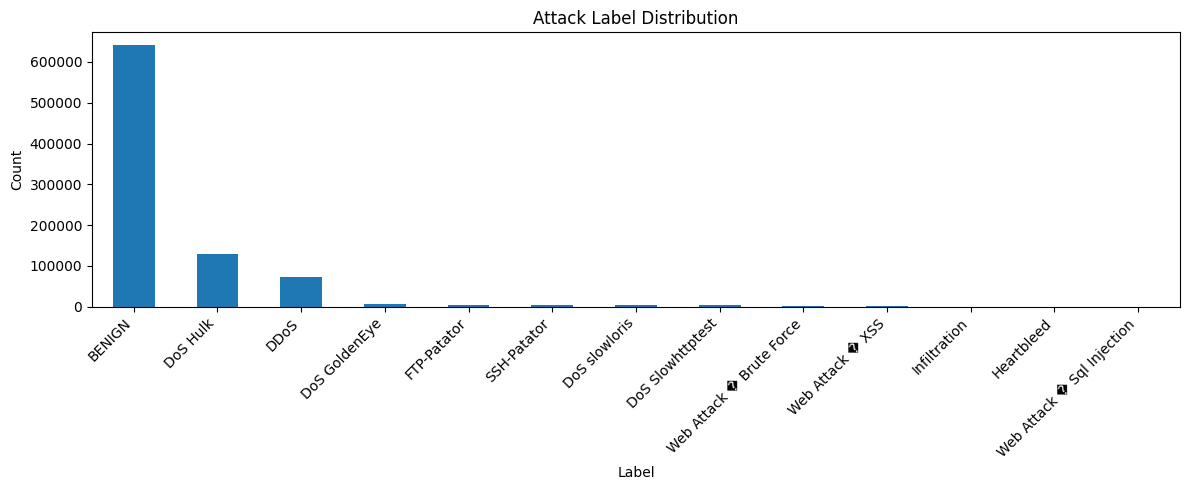

In [2]:
# ── Label distribution ──────────────────────────────────────────────────────
label_counts = df['Label'].value_counts()
print(label_counts)
print(f"\n% distribution:\n{(label_counts / len(df) * 100).round(2)}")

plt.figure(figsize=(12, 5))
label_counts.plot(kind='bar')
plt.title('Attack Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 3. Group Attack Types

Map fine-grained attack labels into five broader categories: **DoS**, **DDoS**, **BruteForce**, **Infiltration**, and **BENIGN**. Rows with unrecognised labels are discarded.

In [3]:
# ── Group similar attack types ───────────────────────────────────────────────
attack_group_mapping = {
    # # BENIGN
    'BENIGN': 'BENIGN',

    # DoS / DDoS
    'DoS Hulk': 'DoS',
    'DoS GoldenEye': 'DoS',
    'DoS Slowloris': 'DoS',
    'DoS Slowhttptest': 'DoS',
    
    'DDoS': 'DDoS',

    # Brute Force
    'FTP-Patator': 'BruteForce',
    'SSH-Patator': 'BruteForce',
    
    'Web Attack � XSS': 'BruteForce',
    'Web Attack � Brute Force': 'BruteForce',

    'Heartbleed': 'Infiltration',
    'Infiltration': 'Infiltration',
}

# Apply mapping; rows with unmapped labels are dropped
df['Label'] = df['Label'].map(attack_group_mapping)
df.dropna(subset=['Label'], inplace=True)

print(f"Groups after mapping : {df['Label'].nunique()}")
for g, cnt in df['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df)*100:.2f}%)")


Groups after mapping : 5
  BENIGN                  640,639  (74.43%)
  DoS                     138,877  (16.13%)
  DDoS                     72,103  (8.38%)
  BruteForce                9,085  (1.06%)
  Infiltration                 46  (0.01%)


## 4. Check Missing and Infinity Values

Identify columns with missing (`NaN`) or infinite values that must be handled before training the model.

In [4]:
# ── Check missing / infinity values ─────────────────────────────────────────
missing = df.isnull().sum()
print("MISSING VALUES\n", missing[missing > 0])

numeric_cols = df.select_dtypes(include=[np.number]).columns
inf_counts = {col: np.isinf(df[col]).sum()
              for col in numeric_cols if np.isinf(df[col]).sum() > 0}
print("\nINFINITY VALUES")
print(inf_counts if inf_counts else "None")


MISSING VALUES
 Dst Port        36
Flow Byts/s    717
dtype: int64

INFINITY VALUES
{'Flow Byts/s': np.int64(275), 'Flow Pkts/s': np.int64(992)}


## 5. Handle Infinity and Missing Values

Replace `±inf` with `NaN`, then fill any remaining missing values with the column **median** to preserve the overall distribution without introducing bias.

In [5]:
# ── Handle inf → NaN → fill with median ─────────────────────────────────────
df_processed = df.copy()
df_processed.replace([np.inf, -np.inf], np.nan, inplace=True)

numeric_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

print(f"NaN remaining : {df_processed.isnull().sum().sum()}")
print(f"Shape         : {df_processed.shape}")


/tmp/ipykernel_1991/2204114694.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[col].fillna(df_processed[col].median(), inplace=True)
/tmp/ipykernel_1991/2204114694.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

NaN remaining : 0
Shape         : (860750, 79)


## 6. Drop Identifier / Metadata Columns

Remove columns that carry no predictive signal and could cause data leakage (e.g. destination port numbers).

In [6]:
# ── Drop identifier / metadata columns ──────────────────────────────────────
keywords = ['dst port']
cols_to_drop = [c for c in df_processed.columns
                if any(k in c.lower() for k in keywords)]

df_processed.drop(columns=cols_to_drop, inplace=True, errors='ignore')
print(f"Dropped : {cols_to_drop}")
print(f"Shape   : {df_processed.shape}")


Dropped : ['Dst Port']
Shape   : (860750, 78)


## 7. Remove Low-Variance Features

Apply `VarianceThreshold` to drop features whose variance falls below 0.01. Such features carry little discriminating power and only add noise.

In [7]:
# ── Remove low-variance features ─────────────────────────────────────────────
from sklearn.feature_selection import VarianceThreshold

y = df_processed['Label']
X = df_processed.drop('Label', axis=1)

selector = VarianceThreshold(threshold=0.01)
X_hv = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()].tolist()

df_processed = pd.DataFrame(X_hv, columns=selected_features)
df_processed['Label'] = y.values

print(f"Features : {X.shape[1]} → {len(selected_features)} (removed {X.shape[1]-len(selected_features)})")
print(f"Shape    : {df_processed.shape}")


Features : 77 → 65 (removed 12)
Shape    : (860750, 66)


## 8. Remove Outliers via Z-Score

Filter out samples where **any** feature has a Z-score magnitude greater than 3, reducing the influence of extreme values on the model.

In [8]:
# ── Remove outliers via Z-score (threshold = 3) ──────────────────────────────
from scipy import stats

X_temp = df_processed.drop('Label', axis=1)
y_temp = df_processed['Label']

mask = (np.abs(stats.zscore(X_temp)) < 3).all(axis=1)
df_processed = X_temp[mask].copy()
df_processed['Label'] = y_temp[mask]

print(f"Removed  : {(~mask).sum()} outliers ({(~mask).mean()*100:.2f}%)")
print(f"Shape    : {df_processed.shape}")


Removed  : 331533 outliers (38.52%)
Shape    : (529217, 66)


## 9. Drop Highly Correlated Features

Remove features with a Pearson correlation coefficient > 0.95 (upper triangle) to reduce redundancy and multicollinearity in the feature set.

In [9]:
# ── Drop highly correlated features (r > 0.95) ───────────────────────────────
X_for_corr = df_processed.drop('Label', axis=1)
upper = X_for_corr.corr().abs().where(
    np.triu(np.ones(X_for_corr.shape[1], dtype=bool), k=1))
to_drop = [c for c in upper.columns if upper[c].max() > 0.95]

df_processed.drop(columns=to_drop, inplace=True)
print(f"Dropped  : {len(to_drop)} correlated features")
print(f"Shape    : {df_processed.shape}")


Dropped  : 31 correlated features
Shape    : (529217, 35)


## 10. Label Encoding

Encode string class labels into integer indices using `LabelEncoder`.

In [10]:
# ── Label encoding ───────────────────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder
import pickle

le = LabelEncoder()
df_processed['Label_Encoded'] = le.fit_transform(df_processed['Label'])

for idx, label in enumerate(le.classes_):
    print(f"{idx}: {label}  ({(df_processed['Label_Encoded']==idx).sum()} samples)")


0: BENIGN  (405067 samples)
1: BruteForce  (4004 samples)
2: DDoS  (47187 samples)
3: DoS  (72954 samples)
4: Infiltration  (5 samples)


## 11. Train / Test Split

Split into **80% training** and **20% test** using stratified sampling to preserve class proportions across both partitions.

In [11]:
# ── Train / test split (stratified 80/20) ────────────────────────────────────
from sklearn.model_selection import train_test_split

X = df_processed.drop(['Label', 'Label_Encoded'], axis=1)
y = df_processed['Label_Encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")


Train : (423373, 34)  |  Test : (105844, 34)


## 12. Feature Scaling

Apply `StandardScaler` to normalise feature magnitudes — essential for gradient-based models like `SGDClassifier`. The fitted scaler is saved to disk.

In [12]:
# ── Feature scaling (StandardScaler) ─────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=X_test.columns,  index=X_test.index)

with open('scaler.pkl1', 'wb') as f:
    pickle.dump(scaler, f)

print(f"Train scaled : {X_train_scaled.shape}  |  Test scaled : {X_test_scaled.shape}")


Train scaled : (423373, 34)  |  Test scaled : (105844, 34)


## 13. Final Feature Summary

Print the final feature count, class count, and per-class sample distribution for both the training and test partitions.

In [13]:
# ── Final feature summary ─────────────────────────────────────────────────────
print(f"Features : {X_train_scaled.shape[1]}  |  Classes : {len(le.classes_)}")
print(f"Train    : {X_train_scaled.shape[0]:,} samples")
print(f"Test     : {X_test_scaled.shape[0]:,} samples")
for i, c in enumerate(X_train_scaled.columns, 1):
    print(f"  {i:3d}. {c}")


Features : 34  |  Classes : 5
Train    : 423,373 samples
Test     : 105,844 samples
    1. Flow Duration
    2. Tot Fwd Pkts
    3. TotLen Fwd Pkts
    4. Fwd Pkt Len Max
    5. Fwd Pkt Len Min
    6. Fwd Pkt Len Mean
    7. Bwd Pkt Len Max
    8. Bwd Pkt Len Min
    9. Flow Byts/s
   10. Flow Pkts/s
   11. Flow IAT Mean
   12. Flow IAT Min
   13. Fwd IAT Min
   14. Bwd IAT Tot
   15. Bwd IAT Mean
   16. Bwd IAT Std
   17. Bwd IAT Max
   18. Bwd IAT Min
   19. Fwd PSH Flags
   20. Bwd Packets/s
   21. FIN Flag Cnt
   22. SYN Flag Cnt
   23. PSH Flag Cnt
   24. ACK Flag Cnt
   25. URG Flag Cnt
   26. Down/Up Ratio
   27. Init Fwd Win Byts
   28. Init Bwd Win Byts
   29. Fwd Act Data Pkts
   30. Fwd Seg Size Min
   31. Active Mean
   32. Active Std
   33. Active Max
   34. Idle Std


---

## 14. Model Training — SVM via SGDClassifier

Import `SGDClassifier` (a stochastic gradient-descent linear SVM approximation) and evaluation utilities.

In [14]:
# # IMPORTS model evaluation
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (classification_report, confusion_matrix, 
                            accuracy_score, precision_recall_fscore_support)
import seaborn as sns


### 14.1 Train the Model

Fit an `SGDClassifier` with the `modified_huber` loss (soft-SVM variant), elastic-net regularisation, and adaptive learning rate.

In [15]:
SGD_classifier = SGDClassifier(
    alpha=0.0001, 
    eta0=0.1, 
    learning_rate='adaptive', 
    loss='modified_huber', 
    max_iter=1000, 
    penalty='elasticnet'
)

SGD_classifier.fit(X_train_scaled, y_train)


,loss,'modified_huber'
,penalty,'elasticnet'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


### 14.2 Training vs Test Accuracy

Compare training and test accuracy to detect potential overfitting. A gap larger than 5% is flagged as overfitting.

In [16]:
# ── Evaluate on train / test set ──────────────────────────────────────────────
y_train_pred = SGD_classifier.predict(X_train_scaled)
y_test_pred  = SGD_classifier.predict(X_test_scaled)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc  = accuracy_score(y_test,  y_test_pred)

print(f"Train accuracy : {train_acc*100:.2f}%")
print(f"Test  accuracy : {test_acc*100:.2f}%")
print(f"Gap            : {(train_acc - test_acc)*100:.2f}%  {'(overfitting)' if train_acc-test_acc>0.05 else '(OK)'}")


Train accuracy : 96.75%
Test  accuracy : 96.84%
Gap            : -0.09%  (OK)


### 14.3 Classification Report

Per-class **precision**, **recall**, **F1-score**, and **support** on the test set.

In [17]:
# ── Classification report ─────────────────────────────────────────────────────
print(classification_report(y_test, y_test_pred, target_names=le.classes_, digits=4, zero_division=0))


              precision    recall  f1-score   support

      BENIGN     0.9903    0.9683    0.9792     81014
  BruteForce     0.9615    0.9675    0.9645       801
        DDoS     0.9954    0.9594    0.9771      9437
         DoS     0.8505    0.9750    0.9085     14591
Infiltration     0.0000    0.0000    0.0000         1

    accuracy                         0.9684    105844
   macro avg     0.7595    0.7740    0.7659    105844
weighted avg     0.9712    0.9684    0.9691    105844



### 14.4 Confusion Matrix

Visualise prediction errors using both raw **counts** and **normalised percentages** side-by-side.

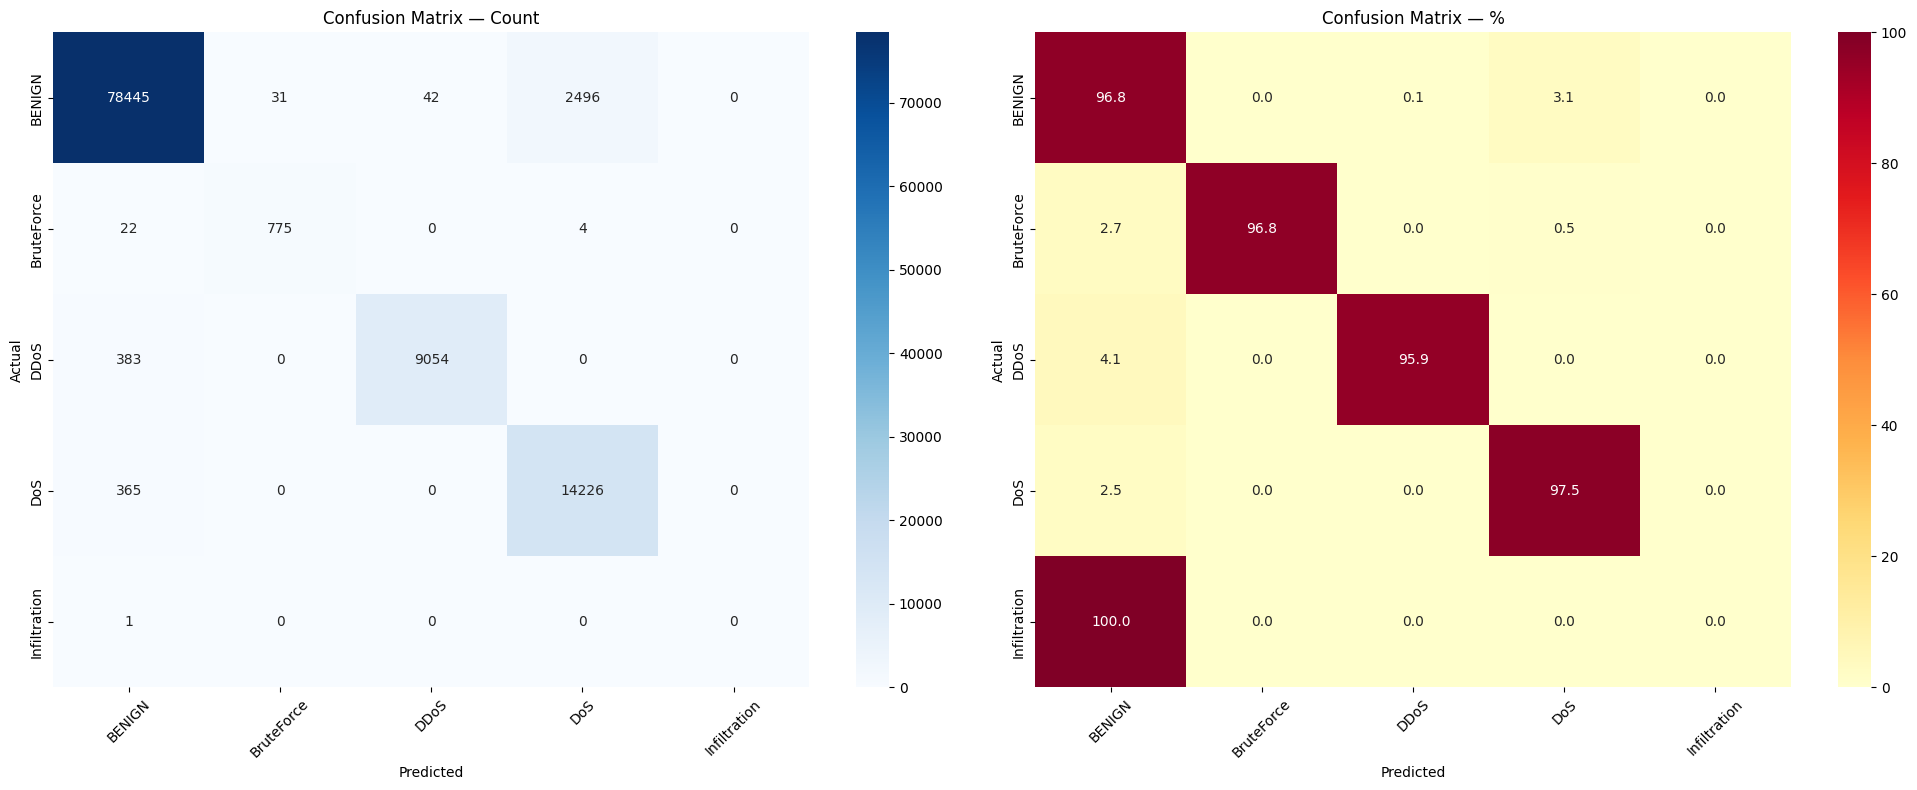

In [18]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_test_pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax1)
ax1.set_title('Confusion Matrix — Count')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.tick_params(axis='x', rotation=45)

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax2)
ax2.set_title('Confusion Matrix — %')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


---

## 15. Cross-Dataset Evaluation on CIC-IDS 2018

Load the CIC-IDS 2018 dataset (balanced, pre-standardised) to evaluate how well the model trained on 2017 data generalises to a different year.

In [19]:
# ── Load CIC-IDS 2018 dataset ────────────────────────────────────────────────
CIC18_PATH = "../../../../dataset/cic2018_balanced_dataset_standardized.parquet"
df18_raw = pd.read_parquet(CIC18_PATH)
print(f"Shape : {df18_raw.shape}")
print(df18_raw['Label'].value_counts())

Shape : (263647, 81)
Label
Benign                      49999
DDOS attack-HOIC            25000
DDoS attacks-LOIC-HTTP      25000
DoS attacks-Hulk            25000
DoS attacks-SlowHTTPTest    25000
DoS attacks-GoldenEye       25000
SSH-Bruteforce              25000
FTP-BruteForce              25000
Infilteration               25000
DoS attacks-Slowloris       10990
DDOS attack-LOIC-UDP         1730
Brute Force -Web              611
Brute Force -XSS              230
SQL Injection                  87
Name: count, dtype: Int64


### 15.1 Group Attack Types (CIC-IDS 2018)

Apply the same attack-type grouping scheme to the 2018 labels so they align with the classes seen during training.

In [20]:
# ── Group similar attack types ───────────────────────────────────────────────
attack_group_mapping_18 = {
    # # BENIGN
    'Benign': 'BENIGN',

    # DoS / DDoS
    'DoS attacks-Hulk': 'DoS',
    'DoS attacks-GoldenEye': 'DoS',
    'DoS attacks-Slowloris': 'DoS',
    'DoS attacks-Slowhttptest': 'DoS',
    
    'DDoS attacks-LOIC-HTTP': 'DDoS',
    'DDoS attacks-LOIC-UDP': 'DDoS',
    'DDOS attack-HOIC': 'DDoS',

    # Brute Force
    'FTP-BruteForce': 'BruteForce',
    'SSH-Bruteforce': 'BruteForce',
    
    'Brute Force -Web': 'BruteForce',
    'Brute Force -XSS': 'BruteForce',

    'Infilteration': 'Infiltration',
    # 'Bot': 'Bot',
}

df18 = df18_raw.copy()
df18['Label'] = df18['Label'].map(attack_group_mapping_18)
df18.dropna(subset=['Label'], inplace=True)

print(f"Groups after mapping : {df18['Label'].nunique()}")
for g, cnt in df18['Label'].value_counts().items():
    print(f"  {g:<20} {cnt:>10,}  ({cnt/len(df18)*100:.2f}%)")


Groups after mapping : 5
  DoS                      60,990  (25.75%)
  BruteForce               50,841  (21.47%)
  DDoS                     50,000  (21.11%)
  BENIGN                   49,999  (21.11%)
  Infiltration             25,000  (10.56%)


### 15.2 Preprocess CIC-IDS 2018

Apply the same preprocessing pipeline (inf/NaN handling, metadata column removal) to the 2018 dataset and identify the shared feature set between 2017 and 2018.

In [21]:
df18_proc = df18.copy()
df18_proc.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in df18_proc.select_dtypes(include=[np.number]).columns:
    if df18_proc[col].isnull().sum() > 0:
        df18_proc[col].fillna(df18_proc[col].median(), inplace=True)

keywords = ['flow id', 'flow_id', 'source ip', 'destination ip',
            'src ip', 'dst ip', 'timestamp', 'source port', 'dst port']
df18_proc.drop(columns=[c for c in df18_proc.columns if any(k in c.lower() for k in keywords)],
               inplace=True, errors='ignore')

train_features = X_train.columns.tolist()
shared_features = [f for f in train_features if f in df18_proc.columns]
missing_in_18 = [f for f in train_features if f not in df18_proc.columns]

print(f"Shape: {df18_proc.shape}  |  Shared: {len(shared_features)}/{len(train_features)}  |  Missing: {len(missing_in_18)}")


Shape: (236830, 79)  |  Shared: 34/34  |  Missing: 0


/tmp/ipykernel_1991/1845869441.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df18_proc[col].fillna(df18_proc[col].median(), inplace=True)
/tmp/ipykernel_1991/1845869441.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

### 15.3 Method 1 — Direct Cross-Test (Shared Features, Scaled)

Retrain `SGDClassifier` on shared features with a fresh `StandardScaler` fit on the 2017 training data, then evaluate on the 2018 test set.

In [22]:
# Method 1: Cross-test on CIC-2018 using shared features
# SGDClassifier was trained on scaled data, so scale X18 using a fresh cross-scaler
from sklearn.preprocessing import StandardScaler

scaler_cross = StandardScaler()
X_train_cross_scaled = scaler_cross.fit_transform(X_train[shared_features])
X_test_cross_scaled  = scaler_cross.transform(X_test[shared_features])

X18_raw = df18_proc[shared_features]
y18_labels = df18_proc['Label']
mask_known = y18_labels.isin(set(le.classes_))
X18_raw, y18_labels = X18_raw[mask_known], y18_labels[mask_known]
y18 = le.transform(y18_labels)
X18 = scaler_cross.transform(X18_raw)

SGD_Shared = SGDClassifier(loss='modified_huber', alpha=0.0001, eta0=0.1,
                            learning_rate='adaptive', max_iter=1000,
                            penalty='elasticnet', random_state=42)
SGD_Shared.fit(X_train_cross_scaled, y_train)

test_cross_acc = accuracy_score(y_test, SGD_Shared.predict(X_test_cross_scaled))
y18_pred = SGD_Shared.predict(X18)
acc18_cross = accuracy_score(y18, y18_pred)

print(f"2017 test accuracy : {test_acc*100:.2f}%  (shared-feat retrain: {test_cross_acc*100:.2f}%)")
print(f"2018 cross accuracy: {acc18_cross*100:.2f}%")
print(f"Cross-dataset drop : {(test_cross_acc - acc18_cross)*100:.2f}%\n")

present_indices = sorted(set(y18))
print(classification_report(y18, y18_pred, labels=present_indices,
                             target_names=le.inverse_transform(present_indices),
                             digits=4, zero_division=0))


2017 test accuracy : 96.84%  (shared-feat retrain: 96.85%)
2018 cross accuracy: 35.41%
Cross-dataset drop : 61.44%

              precision    recall  f1-score   support

      BENIGN     0.2525    0.9778    0.4014     49999
  BruteForce     0.0351    0.0046    0.0082     50841
        DDoS     0.0000    0.0000    0.0000     50000
         DoS     0.9704    0.5694    0.7177     60990
Infiltration     0.0311    0.0002    0.0004     25000

    accuracy                         0.3541    236830
   macro avg     0.2578    0.3104    0.2255    236830
weighted avg     0.3140    0.3541    0.2714    236830



### 15.3 (cont.) Confusion Matrix — Method 1

Confusion matrices (count and percentage) for the 2018 cross-test results from Method 1.

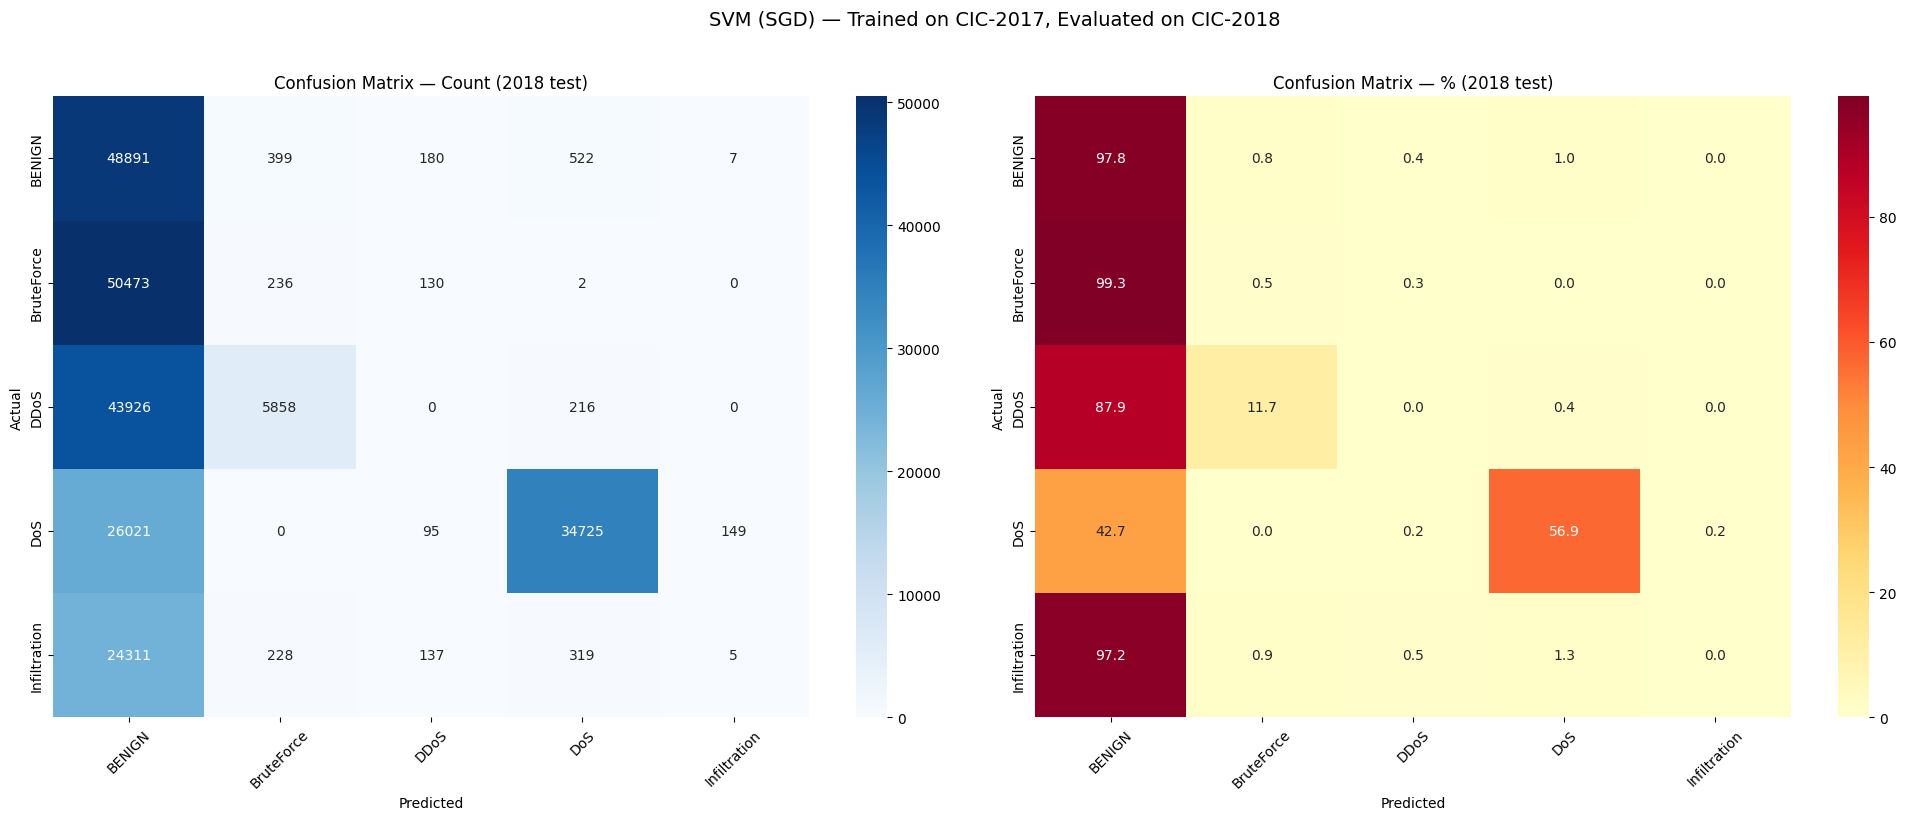

In [23]:
present_names = le.inverse_transform(present_indices)
cm18 = confusion_matrix(y18, y18_pred, labels=present_indices)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm18, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_names, yticklabels=present_names, ax=ax1)
ax1.set_title('Confusion Matrix — Count (2018 test)')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.tick_params(axis='x', rotation=45)

cm18_pct = cm18.astype(float) / cm18.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm18_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=present_names, yticklabels=present_names, ax=ax2)
ax2.set_title('Confusion Matrix — % (2018 test)')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('SVM (SGD) — Trained on CIC-2017, Evaluated on CIC-2018', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


### 15.4 Method 2 — Scaler vs No-Scaler Comparison

Reuse `scaler_cross` from Method 1 and compare cross-dataset accuracy with and without `StandardScaler` normalisation.

In [24]:
# Method 2: Cross-test with a second StandardScaler fit — compare scaler vs no-scaler
# Note: scaler_cross from Method 1 is reused here (fit on X_train[shared_features])
X18_scaled_m2 = scaler_cross.transform(X18_raw)

SGD_Scaler = SGDClassifier(loss='modified_huber', alpha=0.0001, eta0=0.1,
                            learning_rate='adaptive', max_iter=1000,
                            penalty='elasticnet', random_state=42)
SGD_Scaler.fit(X_train_cross_scaled, y_train)

acc17_test_scaled = accuracy_score(y_test, SGD_Scaler.predict(X_test_cross_scaled))
acc18_scaled      = accuracy_score(y18, SGD_Scaler.predict(X18_scaled_m2))

print(f"{'':30} {'No Scaler':>12} {'Scaler':>12}")
print(f"{'-'*55}")
print(f"{'2017 test accuracy':30} {test_acc*100:>11.2f}% {acc17_test_scaled*100:>11.2f}%")
print(f"{'2018 cross accuracy':30} {acc18_cross*100:>11.2f}% {acc18_scaled*100:>11.2f}%")
print(f"{'Cross-dataset drop':30} {(test_cross_acc-acc18_cross)*100:>11.2f}% {(acc17_test_scaled-acc18_scaled)*100:>11.2f}%")


                                  No Scaler       Scaler
-------------------------------------------------------
2017 test accuracy                   96.84%       96.85%
2018 cross accuracy                  35.41%       35.41%
Cross-dataset drop                   61.44%       61.44%


### 15.5 Method 3 — Combined Training (CIC-2017 + CIC-2018)

Retrain `SGDClassifier` on a merged dataset from both years and evaluate on a stratified held-out split, reporting per-source accuracy to measure dataset shift.

In [ ]:
# Method 3: Retrain on CIC-2017 + CIC-2018 combined, evaluate on stratified held-out split
from sklearn.preprocessing import StandardScaler

X17_all = df_processed.drop(['Label', 'Label_Encoded'], axis=1)[shared_features]
y17_all = df_processed['Label']
X18_all = df18_proc[shared_features]
y18_all = df18_proc['Label']

common_classes = set(y17_all.unique()) & set(y18_all.unique())
mask17 = y17_all.isin(common_classes)
mask18 = y18_all.isin(common_classes)

X_combined = pd.concat([X17_all[mask17], X18_all[mask18]], ignore_index=True)
y_combined_labels = pd.concat([y17_all[mask17], y18_all[mask18]], ignore_index=True)
source = pd.Series(['CIC17'] * mask17.sum() + ['CIC18'] * mask18.sum())

le_combined = LabelEncoder()
y_combined = le_combined.fit_transform(y_combined_labels)

X_comb_train, X_comb_test, y_comb_train, y_comb_test, src_train, src_test = \
    train_test_split(X_combined, y_combined, source, test_size=0.2, stratify=y_combined, random_state=42)

scaler_comb = StandardScaler()
X_comb_train_scaled = scaler_comb.fit_transform(X_comb_train)
X_comb_test_scaled  = scaler_comb.transform(X_comb_test)

SGD_combine = SGDClassifier(loss='modified_huber', alpha=0.0001, eta0=0.1,
                             learning_rate='adaptive', max_iter=1000,
                             penalty='elasticnet', random_state=42)
SGD_combine.fit(X_comb_train_scaled, y_comb_train)

acc_combined = accuracy_score(y_comb_test, SGD_combine.predict(X_comb_test_scaled))
acc_17_part  = accuracy_score(y_comb_test[src_test.values == 'CIC17'],
                               SGD_combine.predict(X_comb_test_scaled[src_test.values == 'CIC17']))
acc_18_part  = accuracy_score(y_comb_test[src_test.values == 'CIC18'],
                               SGD_combine.predict(X_comb_test_scaled[src_test.values == 'CIC18']))

print(f"Overall accuracy  : {acc_combined*100:.2f}%")
print(f"CIC-2017 accuracy : {acc_17_part*100:.2f}%")
print(f"CIC-2018 accuracy : {acc_18_part*100:.2f}%")
print(f"Gap               : {abs(acc_17_part - acc_18_part)*100:.2f}%")


### 15.6 Classification Report and Confusion Matrix — Combined Model

Full per-class metrics and side-by-side confusion matrices (count and percentage) for the model trained on the combined 2017 + 2018 dataset.

              precision    recall  f1-score   support

      BENIGN     0.9358    0.9209    0.9283     91014
  BruteForce     0.9120    0.9528    0.9319     10969
        DDoS     0.8842    0.9899    0.9341     19437
         DoS     0.8639    0.9580    0.9085     26789
Infiltration     0.6355    0.0910    0.1592      5001

    accuracy                         0.9113    153210
   macro avg     0.8463    0.7825    0.7724    153210
weighted avg     0.9052    0.9113    0.9007    153210



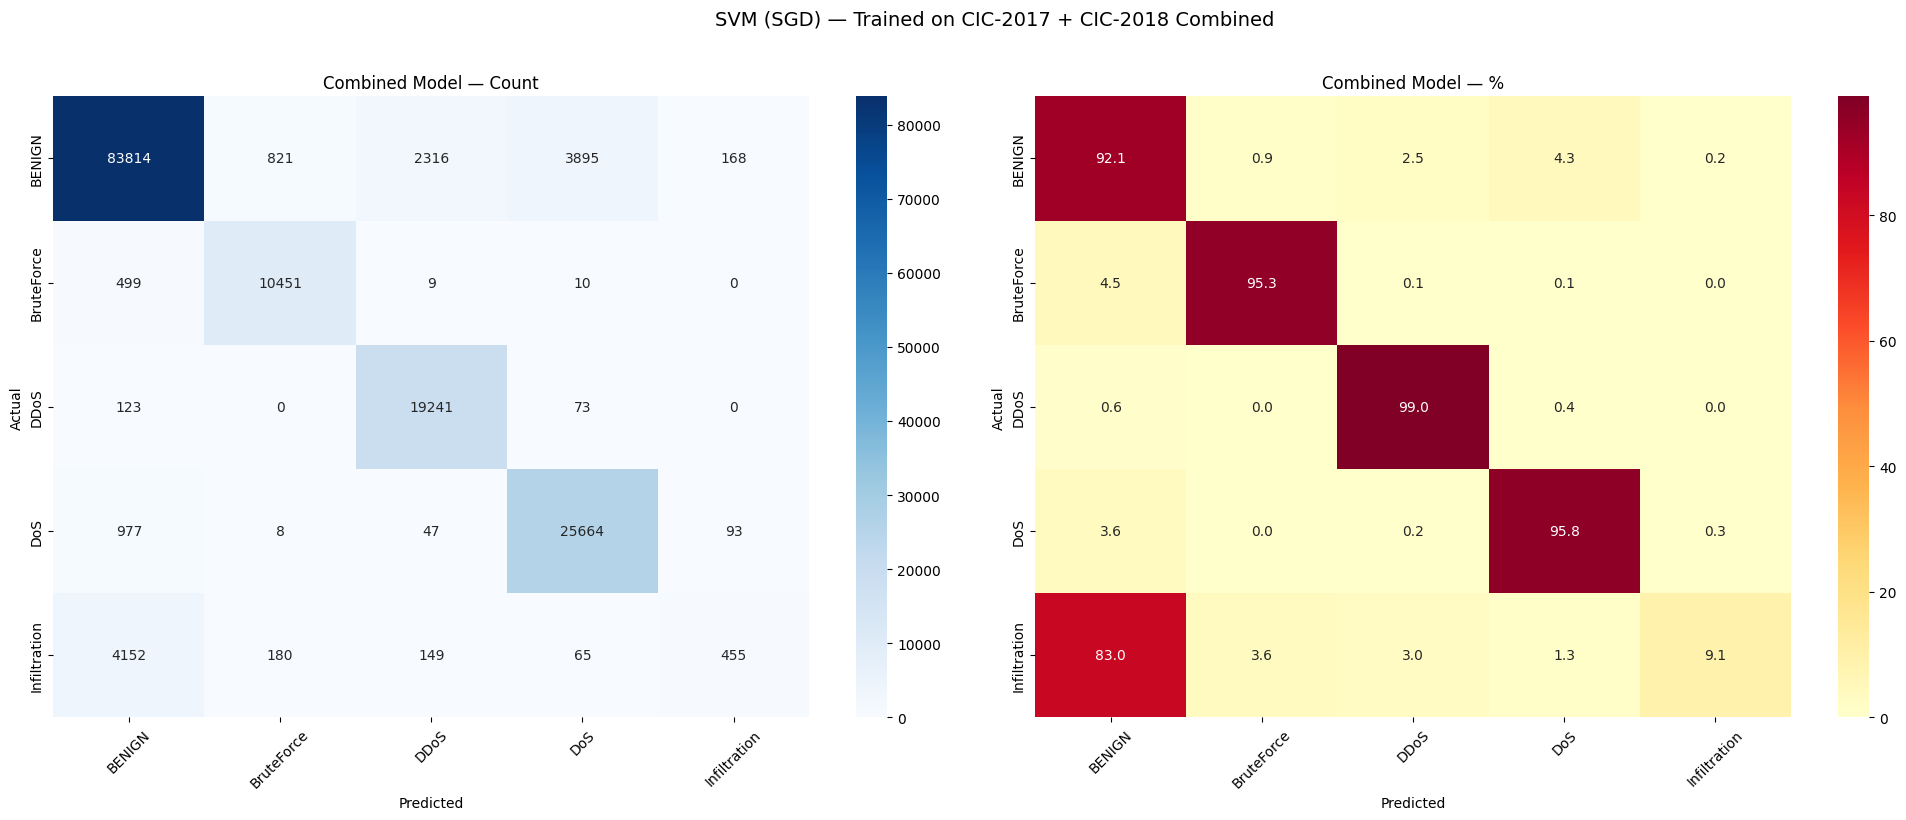

: 

In [ ]:
print(classification_report(y_comb_test, SGD_combine.predict(X_comb_test_scaled),
                             target_names=le_combined.classes_, digits=4, zero_division=0))

cm_combined = confusion_matrix(y_comb_test, SGD_combine.predict(X_comb_test_scaled))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm_combined, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_combined.classes_, yticklabels=le_combined.classes_, ax=ax1)
ax1.set_title('Combined Model — Count')
ax1.set_xlabel('Predicted'); ax1.set_ylabel('Actual')
ax1.tick_params(axis='x', rotation=45)

cm_comb_pct = cm_combined.astype(float) / cm_combined.sum(axis=1, keepdims=True) * 100
sns.heatmap(cm_comb_pct, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=le_combined.classes_, yticklabels=le_combined.classes_, ax=ax2)
ax2.set_title('Combined Model — %')
ax2.set_xlabel('Predicted'); ax2.set_ylabel('Actual')
ax2.tick_params(axis='x', rotation=45)

plt.suptitle('SVM (SGD) — Trained on CIC-2017 + CIC-2018 Combined', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()
